# UNet Inference Demo (Single Image)

**Goal:** Demonstrate UNet inference, mask extraction, corner detection, and warping on a single image.

**Note:** This is a DEMO notebook for visualization. For batch processing of all images, see `04b_batch_warp_from_unet.ipynb`.

**Pipeline:**
1. Load trained model from `best_unet_model.pth`
2. Run inference on one test image
3. Extract corners from mask
4. Warp to top-down view
5. Visualize results

In [ ]:
# Install required packages if not available
import subprocess
import sys

def install_package(package):
    """Install a package if not already installed."""
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

# Install PyTorch and segmentation-models-pytorch if needed
try:
    import torch
    import segmentation_models_pytorch as smp
    print("✓ PyTorch and segmentation-models-pytorch are available")
except ImportError:
    print("Installing required packages...")
    install_package("torch")
    install_package("torchvision")
    install_package("segmentation-models-pytorch")
    import torch
    import segmentation_models_pytorch as smp
    print("✓ Installation complete")

# Standard imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up paths
possible_roots = [
    Path.cwd().parent,  # If running from notebooks/ directory
    Path.cwd(),         # If running from workspace root
]

PROJECT_ROOT = None
for root in possible_roots:
    test_path = root / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Board_coordinates"
    if test_path.exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()

BASE_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Board_coordinates"
MODEL_PATH = PROJECT_ROOT / "notebooks" / "best_unet_model.pth"
TEST_IMG_PATH = BASE_DATA_DIR / "test" / "images" / "8de03901c64a80070048ead3fb0d32bd_jpg.rf.84141f105064b57f9714500f7927f2a4.jpg"

IMAGE_SIZE = 320
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Project root: {PROJECT_ROOT}")
print(f"Model path: {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Test image: {TEST_IMG_PATH}")
print(f"Device: {DEVICE}")

✓ PyTorch and segmentation-models-pytorch are available
Project root: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision
Model path: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/notebooks/best_unet_model.pth
Model exists: True
Test image: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/raw/Chess Pieces Detection Image Dataset/Board_coordinates/test/images/8de03901c64a80070048ead3fb0d32bd_jpg.rf.84141f105064b57f9714500f7927f2a4.jpg
Device: cpu


## Load Model and Run Inference

In [ ]:
def load_model(path):
    """Load trained UNet model with exact architecture from training."""
    # Re-create the exact same architecture used in training
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,  # No need to download weights, we are loading ours
        in_channels=3,
        classes=1,
        activation=None
    )
    # Load the weights
    model.load_state_dict(torch.load(str(path), map_location=DEVICE))
    model.to(DEVICE)
    model.eval()  # Set to evaluation mode
    return model

def predict_image(model, image_path):
    """Run inference on a single image and return mask."""
    # A. Load Image
    if not image_path.exists():
        print(f"Error: Image not found at {image_path}")
        return None, None

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_h, original_w = image.shape[:2]

    # B. Preprocess (Must match training!)
    # Resize
    img_resized = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

    # Normalize (Standard ImageNet stats used by smp)
    preprocessing_fn = smp.encoders.get_preprocessing_fn('resnet34', 'imagenet')
    img_input = preprocessing_fn(img_resized)

    # To Tensor (C, H, W)
    img_tensor = torch.from_numpy(img_input.transpose(2, 0, 1)).float().unsqueeze(0)
    img_tensor = img_tensor.to(DEVICE)

    # C. Inference
    with torch.no_grad():
        output = model(img_tensor)
        # Apply sigmoid since we trained with logits (activation=None)
        prob_mask = torch.sigmoid(output).squeeze().cpu().numpy()

    # D. Post-process (Resize mask back to original size)
    # Threshold at 0.5 to get binary mask (0 or 1)
    binary_mask = (prob_mask > 0.5).astype(np.uint8) * 255
    full_size_mask = cv2.resize(binary_mask, (original_w, original_h), interpolation=cv2.INTER_NEAREST)

    return image, full_size_mask

# Load model and run inference
if MODEL_PATH.exists():
    model = load_model(MODEL_PATH)
    print("✓ Model loaded successfully")

    original_img, pred_mask = predict_image(model, TEST_IMG_PATH)

    if original_img is not None:
        print("✓ Inference complete")
    else:
        print("✗ Inference failed")
else:
    print(f"✗ Model file not found: {MODEL_PATH}")

✓ Model loaded successfully
✓ Inference complete


## Visualize Mask Prediction

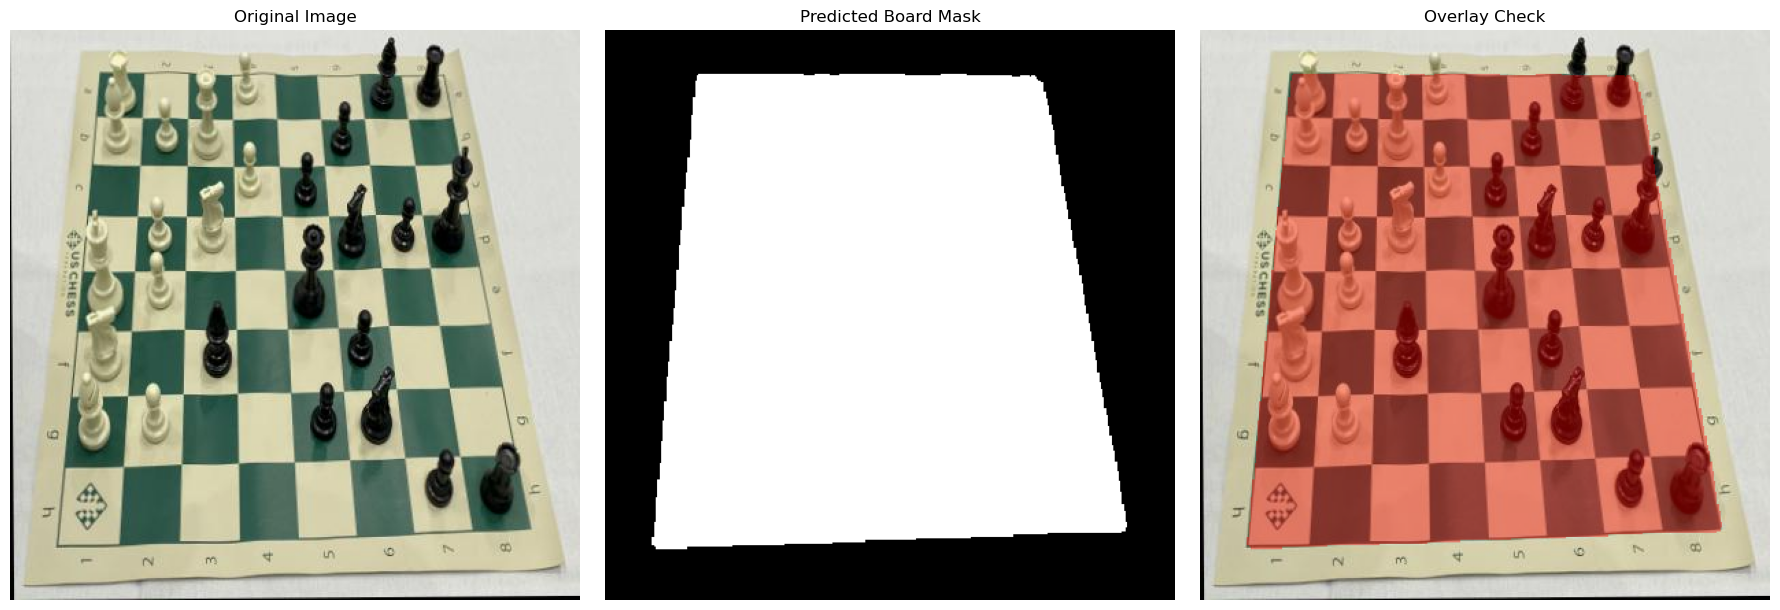

In [ ]:
if 'original_img' in locals() and 'pred_mask' in locals() and original_img is not None:
    # Visualization
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Original Image
    ax[0].imshow(original_img)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    # 2. Predicted Mask (Black & White)
    ax[1].imshow(pred_mask, cmap='gray')
    ax[1].set_title("Predicted Board Mask")
    ax[1].axis('off')

    # 3. Overlay (Mask on Image)
    overlay = original_img.copy()
    overlay[pred_mask == 255] = [255, 0, 0]  # Turn board pixels RED
    blended = cv2.addWeighted(original_img, 0.6, overlay, 0.4, 0)

    ax[2].imshow(blended)
    ax[2].set_title("Overlay Check")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Run inference first")

## Corner Extraction and Warping

In [ ]:
def order_points(pts):
    """
    Orders coordinates: [top-left, top-right, bottom-right, bottom-left].
    """
    rect = np.zeros((4, 2), dtype="float32")

    # Top-left has smallest sum, Bottom-right has largest sum
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    # Top-right has smallest diff, Bottom-left has largest diff
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    return rect

def warp_chessboard(image, mask, output_size=640):
    """Extract corners from mask and warp to top-down view."""
    # 1. Find Contours in the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("Error: No contour found in mask.")
        return None, None

    # 2. Get the largest contour (the board)
    c = max(contours, key=cv2.contourArea)

    # 3. Approximate the contour to a 4-point polygon
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)

    if len(approx) != 4:
        print(f"Warning: Found {len(approx)} corners instead of 4. Using bounding rect.")
        rect = cv2.minAreaRect(c)
        box = cv2.boxPoints(rect)
        approx = np.int0(box)

    # Reshape to (4, 2)
    pts = approx.reshape(4, 2)
    rect = order_points(pts)

    # 4. Define dimensions for the new flattened image
    dst = np.array([
        [0, 0],
        [output_size - 1, 0],
        [output_size - 1, output_size - 1],
        [0, output_size - 1]], dtype="float32")

    # 5. Warp
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (output_size, output_size))

    return warped, rect

print("✓ Corner extraction and warping functions defined")

✓ Corner extraction and warping functions defined


## Visualize Warped Result

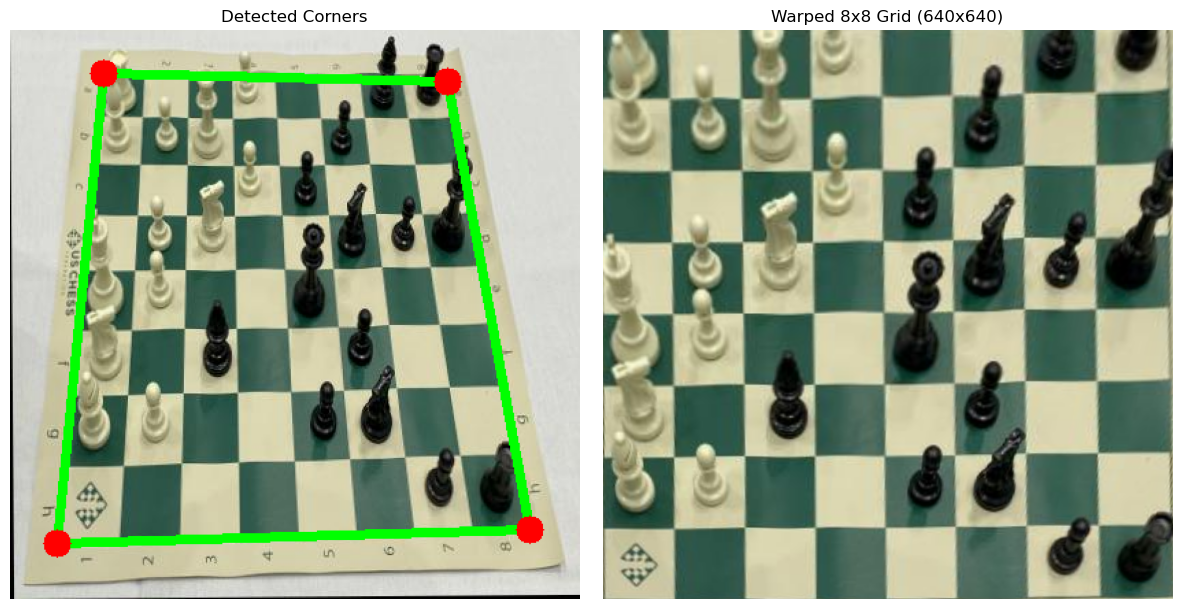

✓ Warping complete. Output size: (640, 640, 3)


In [ ]:
if 'original_img' in locals() and 'pred_mask' in locals() and original_img is not None:
    warped_board, corners = warp_chessboard(original_img, pred_mask, output_size=640)

    if warped_board is not None:
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))

        # Draw corners on original to verify
        debug_img = original_img.copy()
        cv2.drawContours(debug_img, [corners.astype(int)], -1, (0, 255, 0), 5)  # Green box
        for i, point in enumerate(corners):
            cv2.circle(debug_img, (int(point[0]), int(point[1])), 10, (255, 0, 0), -1)  # Red corners

        ax[0].imshow(debug_img)
        ax[0].set_title("Detected Corners")
        ax[0].axis('off')

        ax[1].imshow(warped_board)
        ax[1].set_title("Warped 8x8 Grid (640x640)")
        ax[1].axis('off')

        plt.tight_layout()
        plt.show()

        print(f"✓ Warping complete. Output size: {warped_board.shape}")
    else:
        print("✗ Warping failed")
else:
    print("⚠️ Run inference first")